In [1]:
import pandas as pd

df = pd.read_csv("Diabetes_and_LifeStyle_Dataset_.csv")
df.head()

,Age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,52,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


In [2]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97297 entries, 0 to 97296
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 97297 non-null  int64  
 1   gender                              97297 non-null  object 
 2   ethnicity                           97297 non-null  object 
 3   education_level                     97297 non-null  object 
 4   income_level                        97297 non-null  object 
 5   employment_status                   97297 non-null  object 
 6   smoking_status                      97297 non-null  object 
 7   alcohol_consumption_per_week        97297 non-null  int64  
 8   physical_activity_minutes_per_week  97297 non-null  int64  
 9   diet_score                          97297 non-null  float64
 10  sleep_hours_per_day                 97297 non-null  float64
 11  screen_time_hours_per_day           97297

,Age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,...,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diagnosed_diabetes
count,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,...,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000
mean,50.192699,2.004543,118.942886,5.995214,6.997708,5.997031,0.219657,0.250912,0.079067,25.615093,...,185.984234,54.043537,103.000308,121.466407,111.121792,160.014348,9.063591,6.520338,30.222027,0.600039
std,15.492557,1.418060,84.441920,1.780096,1.093726,2.469805,0.414017,0.433540,0.269845,3.588387,...,32.013395,10.275047,33.390145,43.393422,13.590382,30.938915,4.956342,0.813710,9.065063,0.489892
min,19.000000,0.000000,0.000000,0.000000,3.000000,0.500000,0.000000,0.000000,0.000000,15.000000,...,100.000000,20.000000,50.000000,30.000000,60.000000,70.000000,2.000000,4.000000,2.700000,0.000000
25%,38.000000,1.000000,57.000000,4.800000,6.300000,4.300000,0.000000,0.000000,0.000000,23.200000,...,164.000000,47.000000,78.000000,91.000000,102.000000,139.000000,5.090000,5.970000,23.800000,0.000000
50%,51.000000,2.000000,100.000000,6.000000,7.000000,6.000000,0.000000,0.000000,0.000000,25.600000,...,186.000000,54.000000,102.000000,121.000000,111.000000,160.000000,8.790000,6.520000,29.000000,1.000000
75%,61.000000,3.000000,160.000000,7.200000,7.700000,7.700000,0.000000,1.000000,0.000000,28.000000,...,208.000000,61.000000,126.000000,151.000000,120.000000,181.000000,12.450000,7.070000,35.600000,1.000000
max,90.000000,10.000000,833.000000,10.000000,10.000000,16.800000,1.000000,1.000000,1.000000,39.200000,...,318.000000,98.000000,263.000000,344.000000,172.000000,287.000000,32.220000,9.800000,67.200000,1.000000


In [3]:
X_cluster = df.drop(columns=["diabetes_stage"])

In [4]:
X_cluster = pd.get_dummies(X_cluster, drop_first=True)

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

In [6]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled)

In [7]:
df["cluster"].value_counts()

cluster
2    39279
1    30976
0    27042
Name: count, dtype: int64

In [8]:
cluster_summary = df.groupby("cluster").mean(numeric_only=True)
cluster_summary

,Age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,...,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diagnosed_diabetes
cluster,,,,,,,,,,,,,,,,,,,,,
0,51.982028,2.017232,125.910325,5.864522,6.997996,5.899046,0.099882,0.267214,0.081688,26.892249,...,197.170365,52.571260,115.220768,129.813771,102.789698,134.585460,9.949200,5.821765,29.397367,0.140337
1,41.355759,1.976207,132.733762,6.399283,6.997698,5.988872,0.123128,0.188598,0.051330,22.872036,...,165.109052,57.527376,79.761654,102.706612,105.861796,152.930139,7.013416,6.299007,23.693928,0.509685
2,55.929759,2.018152,103.270399,5.766534,6.997518,6.070923,0.378243,0.288831,0.099137,26.899038,...,194.745513,52.309733,112.913363,130.513837,121.006212,183.107818,10.070683,7.175822,35.937929,0.987780


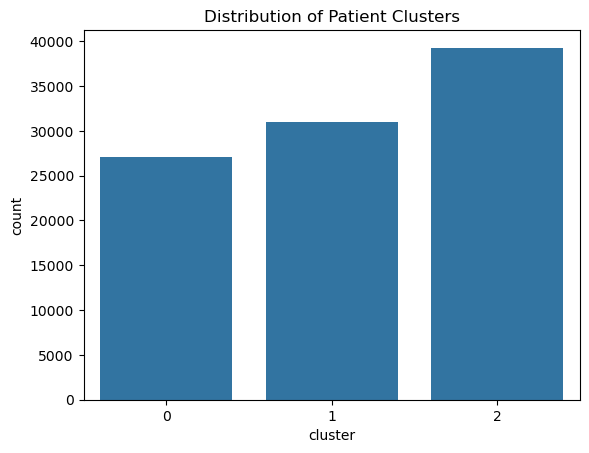

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="cluster", data=df)
plt.title("Distribution of Patient Clusters")
plt.show()

In [10]:
key_features = [
    "bmi",
    "physical_activity_minutes_per_week",
    "diet_score",
    "glucose_fasting",
    "glucose_postprandial",
    "hba1c",
    "cholesterol_total"
]

cluster_summary[key_features]

,bmi,physical_activity_minutes_per_week,diet_score,glucose_fasting,glucose_postprandial,hba1c,cholesterol_total
cluster,,,,,,,
0,26.892249,125.910325,5.864522,102.789698,134.585460,5.821765,197.170365
1,22.872036,132.733762,6.399283,105.861796,152.930139,6.299007,165.109052
2,26.899038,103.270399,5.766534,121.006212,183.107818,7.175822,194.745513


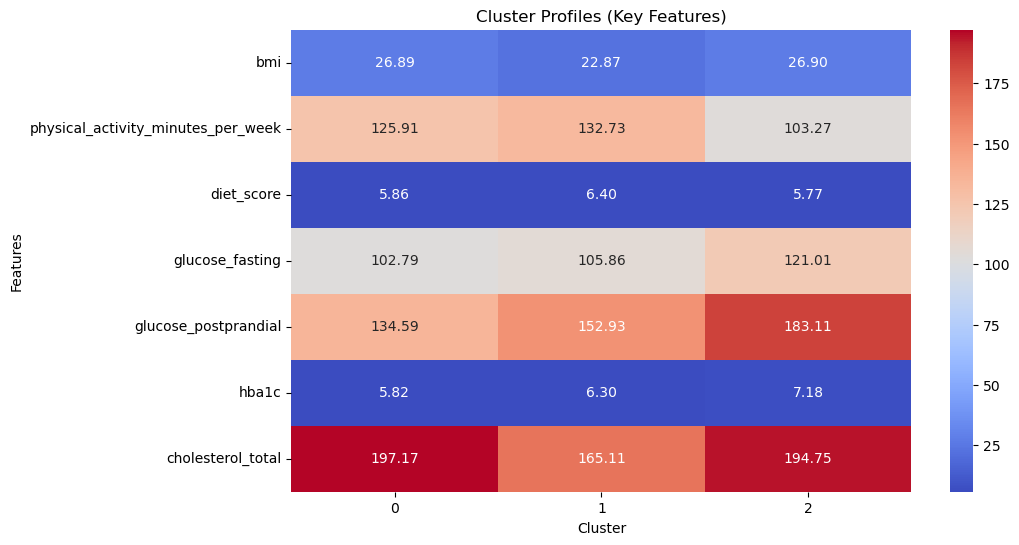

In [11]:
plt.figure(figsize=(10,6))
sns.heatmap(cluster_summary[key_features].T, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Cluster Profiles (Key Features)")
plt.xlabel("Cluster")
plt.ylabel("Features")
plt.show()

Heatmap Interpretation

Cluster 1 shows the healthiest profile, with the lowest BMI, highest physical activity, and best diet score.

Cluster 0 displays moderate risk, with higher BMI and cholesterol but relatively controlled glucose levels.

Cluster 2 shows the highest risk, with the lowest physical activity and significantly elevated glucose and HbA1c levels, indicating poor glycemic control.

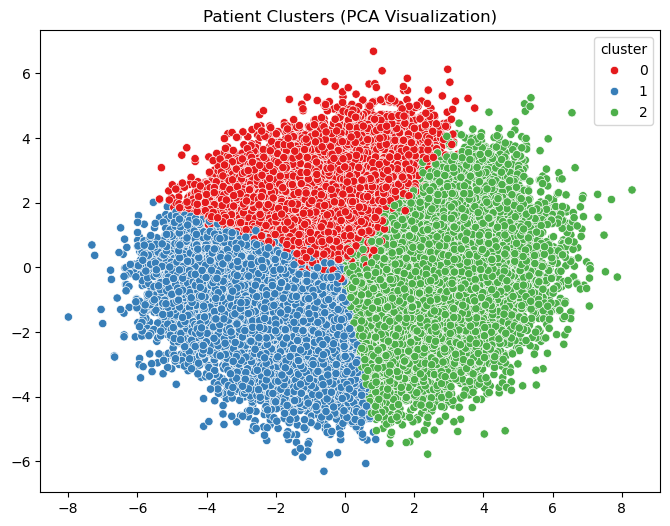

In [12]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df["cluster"], palette="Set1")
plt.title("Patient Clusters (PCA Visualization)")
plt.show()

The PCA plot shows three clearly separated clusters, indicating that the k-means algorithm successfully grouped patients into distinct segments.

Cluster 1 appears well separated from Cluster 2, while Cluster 0 lies between the two, suggesting it represents an intermediate group.

Overall, the visualization confirms that the clusters are meaningful and distinct, supporting the effectiveness of the segmentation.

## 6. Patient Segmentation Results & Insights

The k-means clustering algorithm identified three distinct patient groups based on lifestyle and health-related features.

- Cluster 1 represents the healthiest group, with the lowest BMI (22.87), highest physical activity levels (132.73 minutes/week), and the best diet score (6.40). This group shows relatively controlled glucose levels and lower diabetes risk indicators.

- Cluster 0 represents an intermediate-to-high risk group. Although physical activity levels are moderate (125.91 minutes/week), this group has a higher BMI (26.89), elevated cholesterol levels (197.17), and moderate glucose levels. These patterns suggest early metabolic risk.

- Cluster 2 represents the highest-risk group. This cluster is characterized by the lowest physical activity (103.27 minutes/week), poorer diet score (5.77), and significantly elevated glucose levels (121 fasting, 183 postprandial) and HbA1c (7.18). This group also shows the highest likelihood of diabetes diagnosis.

These results demonstrate a clear relationship between lifestyle behaviors and diabetes risk, where reduced physical activity, poorer diet, and higher BMI contribute to worsening metabolic health.

### Actionable Recommendations

- Cluster 1 (Low Risk): Maintain current healthy lifestyle habits, including regular physical activity and balanced diet, to prevent future risk.

- Cluster 0 (At Risk): Implement targeted lifestyle interventions such as improved diet quality, weight management, and increased physical activity to prevent progression to diabetes.

- Cluster 2 (High Risk): Immediate clinical intervention is required. Patients in this group should receive medical monitoring, structured lifestyle programs, and glucose management strategies.

## 7. Key Driver Analysis using SHAP

While clustering helps group patients based on similarities, it does not explain which features are most important in determining diabetes risk.

To address this, SHAP (Shapley Additive Explanations) is used to identify the key lifestyle and health factors driving predictions in the classification model, as well as the factors influencing patient segmentation.

Due to computational limitations and the large dataset size, a representative sample was used for SHAP analysis. This approach ensures efficient computation while preserving the overall data distribution and feature importance patterns.

In [46]:
pip install joblib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [50]:
X_model = df.drop([
    "diabetes_stage",
    "diabetes_risk_score",
    "glucose_fasting",
    "glucose_postprandial",
    "hba1c",
    "insulin_level"
], axis=1)

X_model = pd.get_dummies(X_model, drop_first=True)

In [51]:
import joblib

model = joblib.load("best_model.pkl")

In [52]:
X_model = X_model.reindex(columns=model.feature_names_in_, fill_value=0)

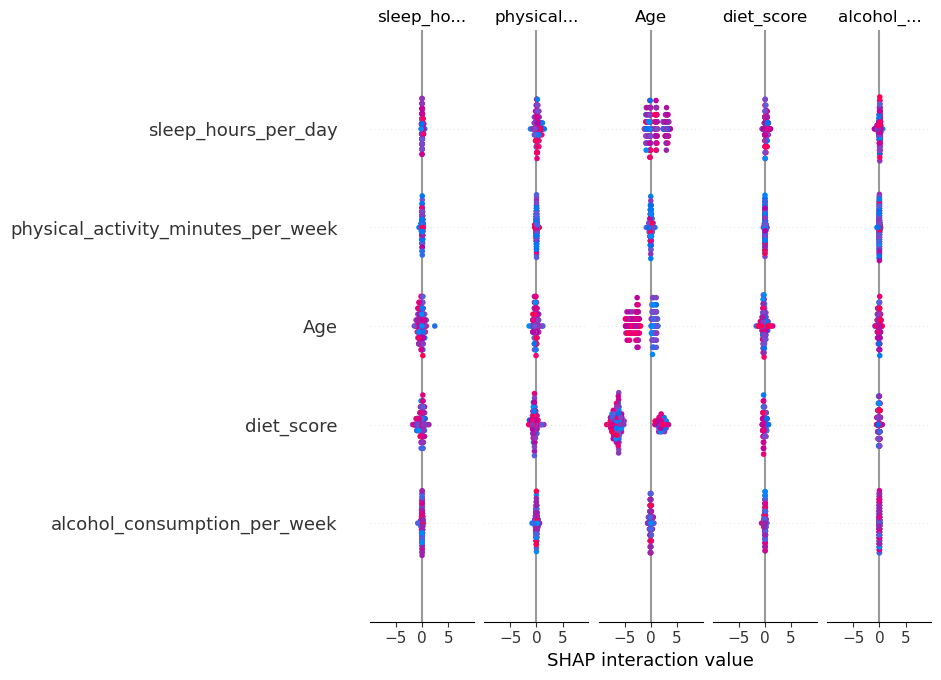

In [53]:
import shap

X_sample = X_model.sample(200, random_state=42)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample)

### Interpretation of SHAP Summary Plot

The SHAP summary plot provides insights into the most influential features affecting diabetes risk predictions. The features are ranked in order of importance from top to bottom.

- **Sleep Hours per Day** is the most influential feature, indicating that sleep patterns play a significant role in diabetes risk. Both insufficient and irregular sleep may contribute to higher risk.
- **Physical Activity (minutes per week)** shows a strong inverse relationship with diabetes risk. Lower activity levels increase risk, while higher activity levels reduce it.
- **Age** is an important factor, with older individuals generally showing higher predicted risk.
- **Diet Score** significantly impacts predictions, where poor dietary habits increase diabetes risk and healthier diets reduce it.
- **Alcohol Consumption per Week** has a less consistent effect, suggesting it is a secondary factor compared to other lifestyle variables.

Overall, the SHAP analysis highlights that lifestyle-related factors are critical drivers of diabetes risk predictions.

In [54]:
from sklearn.ensemble import RandomForestClassifier

rf_surrogate = RandomForestClassifier(random_state=42)
rf_surrogate.fit(X_model, df["cluster"])

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


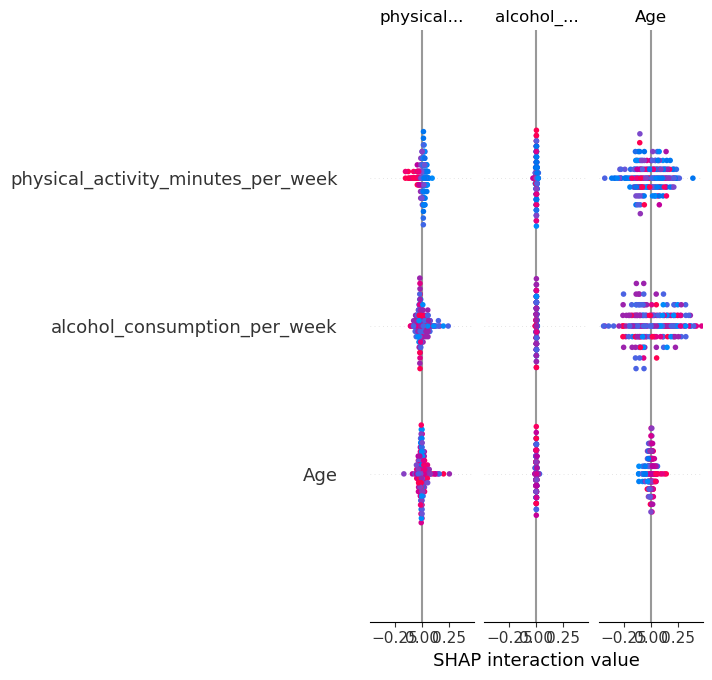

In [55]:
explainer_cluster = shap.TreeExplainer(rf_surrogate)
shap_values_cluster = explainer_cluster.shap_values(X_sample)

shap.summary_plot(shap_values_cluster, X_sample)

### SHAP Interpretation for Clustering

SHAP analysis was applied to a surrogate Random Forest model trained on cluster labels to interpret the key drivers of patient segmentation.

- **Physical activity** emerged as the most important feature, indicating that patients are primarily grouped based on their activity levels. Lower activity levels are associated with less healthy clusters, while higher activity levels correspond to healthier groups.
- **Alcohol consumption** also contributes to cluster differentiation, suggesting that drinking habits play a role in defining lifestyle patterns among patients.
- **Age** has a relatively smaller impact, indicating that clustering is driven more by lifestyle behaviors than by demographic factors.

Overall, the clustering results highlight that lifestyle factors are the primary drivers of patient segmentation, enabling targeted interventions for different groups.